# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, levene, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**
-
---



In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


---
✍️ **Hallazgos preliminares**
-

El dataset contiene **40,000 filas y 9 columnas.** Todas las columnas tienen el **tipo de dato correcto:** user_id, date, landing, region, dispositivo, traffic_source y user_type son cadenas de texto (object); converted es entero (int64); y gasto es flotante (float64).

El dataset no tiene valores ausentes en ninguna columna. **No se requiere limpieza adicional.**

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)


**1.2 Análisis exploratorio y revisión de calidad de datos**
-
Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
print(f'Usuarios Únicos: {df["user_id"].nunique()}')
print(f'IDs duplicados : {df["user_id"].duplicated().sum()}')

Usuarios Únicos: 40000
IDs duplicados : 0


 **Variable `date`**  Explorar rango de fechas

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
print('\nResumen estadístico de gasto (todos los usuarios):')
print()
print(df['gasto'].describe())


Resumen estadístico de gasto (todos los usuarios):

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [ ]:
# Resumen estadístico de usuarios que se convirtieron
print('\nResumen estadístico de gasto (usuarios que convirtieron):')
print()
print(df[df['converted'] == 1]['gasto'].describe())


Resumen estadístico de gasto (usuarios que convirtieron):

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64


 **Variables categóricas**
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing','region', 'dispositivo', 'traffic_source', 'user_type', 'converted']:
    print(f'\n{col}:')
    print(df[col].value_counts())


Conteo de categorías:

landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

converted:
0    34294
1     5706
Name: converted, dtype: int64


In [ ]:
#Calculo de la tasa de conversión general
Tasa_de_conversion_general = df['converted'].sum()/ 40000 *100
print(f'Tasa de conversión general: {Tasa_de_conversion_general}')

Tasa de conversión general: 14.265


---
✍️ **Hallazfos premiliminares -categorías esperadas del experimento ( A y B)**:
-

- **`landing`:** Distribución balanceada: A (19,982) y B (20,018). Los grupos son comparables.

*Otros hallazgos:*
-
- **`user_id`:** Los 40,000 registros tienen identificadores únicos — no hay
usuarios duplicados. El primer supuesto de independencia de observaciones se cumple.

- **`date`:** El experimento abarca del 1 al 28 de enero de 2026 (28 días).

- **`dispositivo`, `traffic_source`, `user_type`, `converted`:** Solo contienen valores esperados. No hay categorías mal escritas ni valores atípicos.

- **`gasto`:** El 75% de los valores es 0.0, correspondiente a usuarios que no convirtieron. Entre quienes sí convirtieron, el gasto promedio es ~$65.37.

- **La tasa de conversión general es del 14.26%**
  
Todas las columnas tienen valores esperados. **El dataset está listo para el análisis estadístico.**


---


**💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)**
-

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


---

In [ ]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
print(f'\nUsuarios convertidos — Página A: {len(gasto_A):,}')
print(f'Usuarios convertidos — Página B: {len(gasto_B):,}')
print(f'\nGasto promedio Página A: ${gasto_A.mean():.2f}')
print(f'Gasto promedio Página B: ${gasto_B.mean():.2f}')


Usuarios convertidos — Página A: 2,512
Usuarios convertidos — Página B: 3,194

Gasto promedio Página A: $61.09
Gasto promedio Página B: $68.75


---
**2.1 Prueba de Levene (verificar varianzas antes del t-test)**
-
Antes de aplicar la prueba t, verificamos si las varianzas de ambos grupos son iguales. Esto determina el parámetro `equal_var` que usaremos.

**Hipótesis:**
- **H₀:** Las varianzas de los grupos A y B son iguales.
- **H₁:** Las varianzas de los grupos A y B son diferentes.



---

In [ ]:
# Aplicar prueba
from scipy.stats import levene

# Prueba de varianzas iguales
l_stat, p_value_var = levene(gasto_A, gasto_B)

print(f'Estadístico de Levene: {l_stat:.4f}')
print(f'Valor p: {p_value_var:.4f}')

alpha = 0.05
if p_value_var < alpha:
    print('\n ✅Rechazamos H₀: hay evidencia de varianzas diferentes')
else:
    print('\n ❌No rechazamos H₀: no hay evidencia de varianzas diferentes')


Estadístico de Levene: 29.1765
Valor p: 0.0000

 ✅Rechazamos H₀: hay evidencia de varianzas diferentes


---
**Prueba t de Student**
-
**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio es diferente entre la página A y la página B.

Nivel de significancia: **α = 0.05**


---

In [ ]:
# Aplicar prueba t de Student
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f'Estadístico t: {t_stat:.4f}')
print(f'Valor p: {p_value:.6f}')
print()

alpha = 0.05
if p_value < alpha:
    print('✅ Rechazamos la hipótesis nula: hay evidencia de una diferencia en el gasto promedio(p < 0.05)')
else:
    print('❌ No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia (p ≥ 0.05)')

Estadístico t: -9.4810
Valor p: 0.000000

✅ Rechazamos la hipótesis nula: hay evidencia de una diferencia en el gasto promedio(p < 0.05)


---
**2.2📝 Conclusión e interpretación**
-

**Decisión:**  Se **rechaza la hipótesis nula** (p < 0.05). Los datos proporcionan evidencia estadística de que el gasto promedio no es igual entre la página A y la página B.

**Interpretación de negocio:**
La página B genera un gasto promedio significativamente mayor ($68.75) que la página A ($61.09) entre los usuarios que convirtieron. Esto representa una diferencia de ~$7.66 por usuario convertido, lo que sugiere que la página B es más efectiva para maximizar el valor económico por conversión.

---


**📈 Paso 3: Comparar la tasa de conversión entre la página A y B**
-
Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

---
**Prueba z de proporciones**
-
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y en la página B. Cualquier diferencia se debe al azar.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

Nivel de significancia: **α = 0.05**

---

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()


print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Diferencia den Tasa de conversion

Tasa_de_conversion= (conversiones)/ (totales) *100
print()
print(f'Tasa de conversión : {Tasa_de_conversion}')



Tasa de conversión : landing
A    12.571314
B    15.955640
Name: converted, dtype: float64


In [ ]:
# Aplicar prueba
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]
#prueba z de proporciones
z_stat, p_value = proportions_ztest(exitos, observaciones)

# Visualizar resultados
print(f'Estadístico z: {z_stat:.4f}')
print(f'Valor p: {p_value:.6f}')
print()

alpha = 0.05
if p_value < alpha:
    print('✅ Rechazamos la hipótesis nula: hay evidencia de una diferencia en la tasa de conversión entre la página A y B')
else:
    print('❌ No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia entre la página A y B')

Estadístico z: -9.6774
Valor p: 0.000000

✅ Rechazamos la hipótesis nula: hay evidencia de una diferencia en la tasa de conversión entre la página A y B


---
**📝 Conclusión e interpretación**
-
**Decisión:**
Se rechaza la hipótesis nula (p < 0.0001). Hay evidencia estadística de **una diferencia en la tasa de conversión entre ambas páginas.**

**Interpretación de negocio:**
Con base en la prueba z para proporciones, **encontramos evidencia estadística** de que la tasa de conversión difiere entre las páginas A y B. La página B presenta una diferencia de 3.39%,  mas que la página A ***(15.96% vs 12.57%).***

---

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

---

**Prueba Chi-cuadrada de independencia**
-
**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico y la conversión son independientes (no existe asociación entre ellas).
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

Nivel de significancia: **α = 0.05**

In [ ]:
# Tabla de contingencia: fuente de tráfico vs conversión
tabla_traffic = pd.crosstab(df['traffic_source'], df['converted'])
tabla_traffic.columns = ['No convirtió', 'Convirtió']
print('\nTabla de contingencia:\n')
print(tabla_traffic)


Tabla de contingencia:

                No convirtió  Convirtió
traffic_source                         
Ads                    10176       1759
Email                   5205        918
Organic                15507       2480
Referral                3406        549


In [ ]:
# Proporciones por fuente de tráfico
print('\nTasa de conversión por fuente de tráfico (%):\n')
print((pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100))



Tasa de conversión por fuente de tráfico (%):

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


In [ ]:
# Aplicar prueba Chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_traffic)

print(f'Estadístico χ²  : {chi2_stat:.4f}')
print(f'Grados de libertad: {dof}')
print(f'Valor p         : {p_value:.6f}')
print('\nFrecuencias esperadas:')
print(pd.DataFrame(expected, index=tabla_traffic.index, columns=tabla_traffic.columns).round(2))
print()

alpha = 0.05
if p_value < alpha:
    print('✅ Rechazamos la hipótesis nula: existe evidencia de asociación entre fuente de tráfico y conversión')
else:
    print('❌ No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre fuente de tráfico y conversión ')

Estadístico χ²  : 8.6621
Grados de libertad: 3
Valor p         : 0.034138

Frecuencias esperadas:
                No convirtió  Convirtió
traffic_source                         
Ads                 10232.47    1702.53
Email                5249.55     873.45
Organic             15421.15    2565.85
Referral             3390.82     564.18

✅ Rechazamos la hipótesis nula: existe evidencia de asociación entre fuente de tráfico y conversión


---

**📝 Conclusión e interpretación**
-
**Decisión:**  
**Se rechaza la hipótesis nula** (p = 0.034 < 0.05). Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

**Interpretación de negocio:** Con base en la prueba Chi-cuadrada de independencia, encontramos evidencia estadística de que la conversión está asociada a la fuente de tráfico. Los canales **Email (15.0%) y Ads (14.7%)** presentan las mayores tasas de conversión. Sin embargo, **la diferencia entre canales es pequeña**, por lo que el efecto práctico es moderado.

---

**👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión**
-

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

---
**Prueba Chi-cuadrada de independencia**
-
**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario y la conversión son independientes (no existe asociación entre ellos).
  
- **Hipótesis alternativa (H₁):** Existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.

Nivel de significancia: **α = 0.05**

---

In [ ]:
# Tabla de contingencia: tipo de usuario vs conversión
tabla_user = pd.crosstab(df['user_type'], df['converted'])
tabla_user.columns = ['No convirtió', 'Convirtió']
print()
print('Tabla de contingencia:\n')
print(tabla_user)


Tabla de contingencia:

            No convirtió  Convirtió
user_type                          
Nuevo              22295       3738
Recurrente         11999       1968


In [ ]:
# Proporciones
print('\nTasa de conversión por tipo de usuario (%):\n')
print((pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100))


Tasa de conversión por tipo de usuario (%):

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


In [ ]:
# Aplicar prueba chi

chi2_u, p_u, dof_u, expected_u = chi2_contingency(tabla_user)

print(f'Estadístico χ²    : {chi2_u:.4f}')
print(f'Grados de libertad: {dof_u}')
print(f'Valor p           : {p_u:.6f}')
print('\nFrecuencias esperadas:')
print(pd.DataFrame(expected_u, index=tabla_user.index, columns=tabla_user.columns).round(2))
print()

alpha = 0.05
if p_u < alpha:
    print('✅ Rechazamos la hipótesis nula: hay evidencia de asociación entre tipo de usuario y conversión ')
else:
    print('❌ No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación')

Estadístico χ²    : 0.5135
Grados de libertad: 1
Valor p           : 0.473634

Frecuencias esperadas:
            No convirtió  Convirtió
user_type                          
Nuevo           22319.39    3713.61
Recurrente      11974.61    1992.39

❌ No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación


---

**📝 Conclusión e interpretación**
-
**Decisión:**  
**No se rechaza la hipótesis nula** (p = 0.474 > 0.05). No hay evidencia suficiente para afirmar que el tipo de usuario y la conversión están asociados.

**Interpretación de negocio:** Las tasas de conversión entre usuarios Nuevos (14.36%) y Recurrentes (14.09%) son prácticamente idénticas. La diferencia observada puede mostrar variaciones normales del azar. Vemos que el tipo de usuario **no es un factor diferenciador en la probabilidad de conversión** dentro de este experimento, lo que indica que **la landing page tiene un efecto uniforme para ambos perfiles.**

---

--
**📊 Paso 6: Visualizar los resultados de variables categóricas**
-

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

---
**Relación entre la fuente de tráfico y la conversión**
-

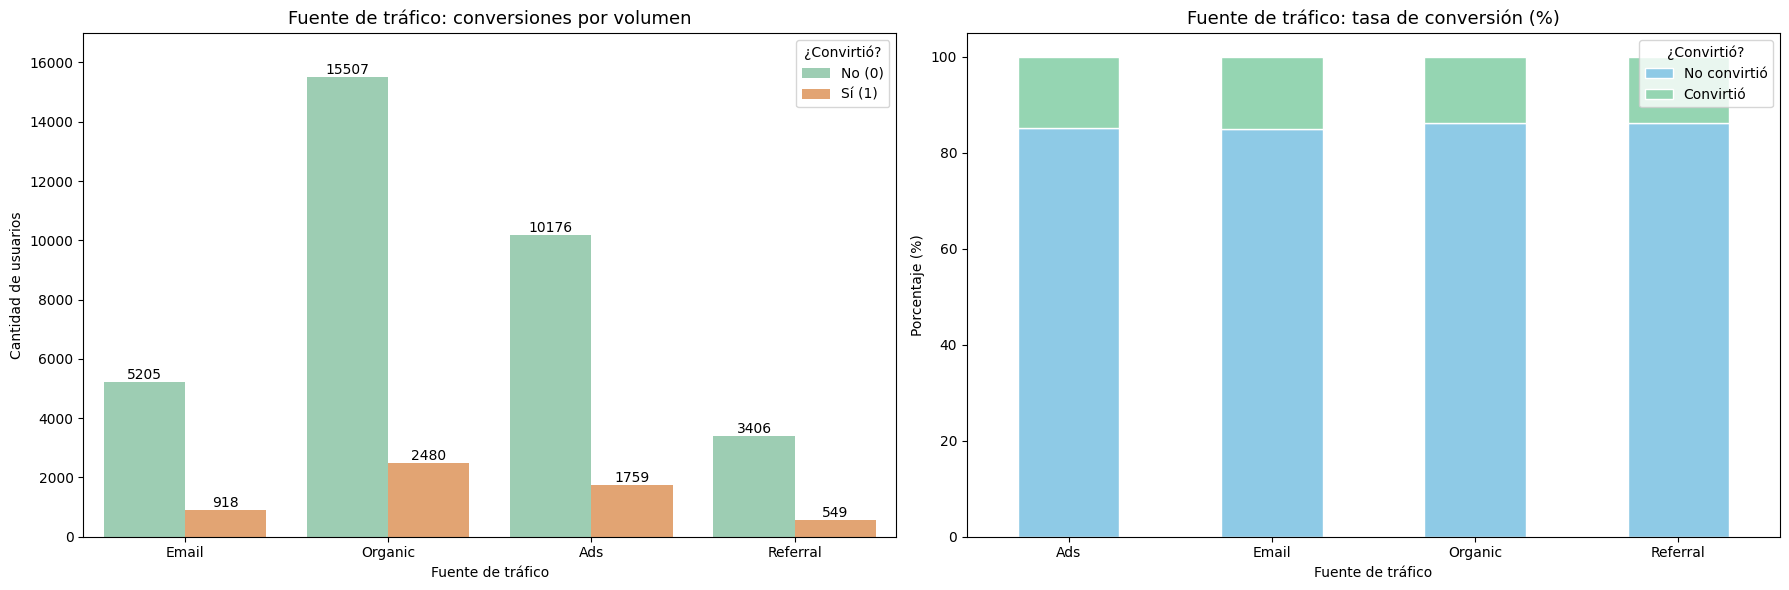

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras agrupadas — cantidades absolutas
sns.countplot(data=df, x='traffic_source', hue='converted',
              palette={0: '#95D5B2', 1: '#F4A261'}, ax=axes[0])
for bar in axes[0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0].text(x=bar.get_x() + bar.get_width() / 2,
                     y=height, s=int(height),
                     ha='center', va='bottom', fontsize=10)
axes[0].set_title('Fuente de tráfico: conversiones por volumen', fontsize=13)
axes[0].set_xlabel('Fuente de tráfico')
axes[0].set_ylabel('Cantidad de usuarios')
axes[0].set_ylim(0, 17000)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])



# Barras apiladas — proporciones
tabla_norm = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_norm.columns = ['No convirtió', 'Convirtió']
tabla_norm.plot(kind='bar', stacked=True, ax=axes[1], color=['#8ecae6', '#95d5b2'], edgecolor='white')
axes[1].set_title('Fuente de tráfico: tasa de conversión (%)', fontsize=13)
axes[1].set_xlabel('Fuente de tráfico')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='¿Convirtió?', loc='upper right')

plt.tight_layout()
plt.show()




---
✍️ **Comentario**:
-
**Cantidades absolutas:** El canal Organic genera el mayor volumen de conversiones absolutas por ser el canal con más usuarios. Sin embargo, esto no indica que sea el más eficiente.

**Proporciones:** Al comparar tasas, Email y Ads presentan la mayor efectividad relativa (~15%), mientras que Organic y Referral se ubican levemente por debajo. Referal presento la tasa más baja lo que puede presentar un reto para los departamentos de mercadeo y servicio al cliente  


### Relación entre el tipo de usuario y la conversión

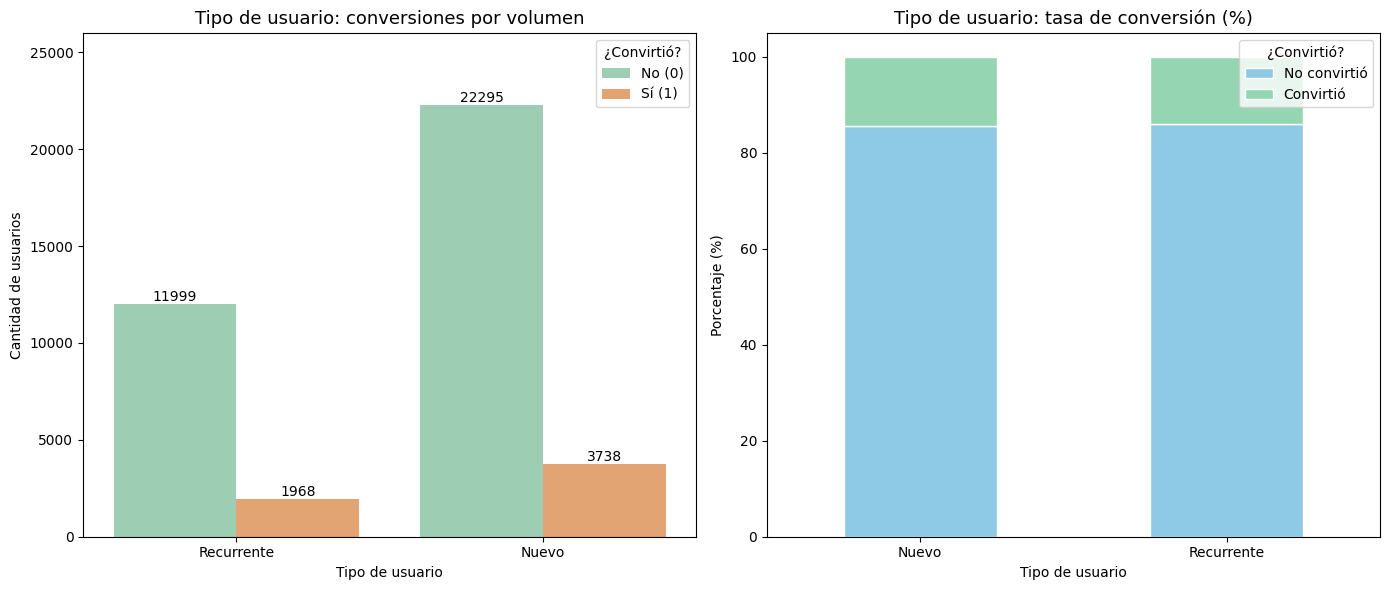

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras agrupadas — cantidades absolutas
sns.countplot(data=df, x='user_type', hue='converted',
              palette={0: '#95D5B2', 1: '#F4A261'}, ax=axes[0])
for bar in axes[0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0].text(x=bar.get_x() + bar.get_width() / 2,
                     y=height, s=int(height),
                     ha='center', va='bottom', fontsize=10)
axes[0].set_title('Tipo de usuario: conversiones por volumen', fontsize=13)
axes[0].set_xlabel('Tipo de usuario')
axes[0].set_ylabel('Cantidad de usuarios')
axes[0].set_ylim(0, 26000)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Barras apiladas — proporciones
tabla_user_norm = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_user_norm.columns = ['No convirtió', 'Convirtió']
tabla_user_norm.plot(kind='bar', stacked=True, ax=axes[1], color=['#8ecae6', '#95d5b2'], edgecolor='white')
axes[1].set_title('Tipo de usuario: tasa de conversión (%)', fontsize=13)
axes[1].set_xlabel('Tipo de usuario')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='¿Convirtió?', loc='upper right')

plt.tight_layout()
plt.show()

---
✍️ **Comentario**:
-

**Cantidades absolutas:** Los usuarios **Nuevos** generan más conversiones en volumen, simplemente porque son más en el experimento (26,033 vs 13,967).

**Proporciones:** Las tasas de conversión de Nuevos (14.36%) y Recurrentes (14.09%) son prácticamente idénticas. Esto confirma visualmente el resultado estadístico del Paso 5: **el tipo de usuario no está asociado a la conversión.** La landing page es igualmente efectiva para ambos perfiles.

---

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

---
**Paso 7. Insight Ejecutivo para Stakeholders**
-

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

---
***🌟 Insight Ejecutivo basado en el Experimento A/B***
-

#### 7.1.1 🔍 Comparación de páginas (A vs B)

**Gasto promedio por usuario que convirtió:**
- Página A: **$61.09** | Página B: **$68.75**
- La página B genera **$7.66 más por cliente** en promedio.
- Diferencia **estadísticamente significativa** (prueba t de Student, p < 0.0001).


---


**Interpretación:** Existe evidencia estadística de que el gasto promedio difiere entre las páginas. Los usuarios de la página B no solo convierten más, sino que también gastan más. La estadística informa la diferencia; el negocio decide si la magnitud justifica el cambio.

---

**Tasa de conversión:**
- Página A: **12.57%** | Página B: **15.96%**
- La página B tiene una tasa **3.39 puntos porcentuales mayor**.
- Diferencia **estadísticamente significativa** (prueba z de proporciones, p < 0.0001).

**Interpretación:** Con base en la prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversión. Por cada 1,000 usuarios, la página B generaría ~34 conversiones adicionales respecto a la página A.

---

#### 7.1.2 📊 Segmentación por fuente de tráfico

- Los canales **Email (15.0%) y Ads (14.7%)** presentan las mayores tasas de conversión.
- **Organic** genera el mayor volumen absoluto de conversiones por ser el canal con más usuarios.
- La diferencia entre canales es **estadísticamente significativa** (χ² = 8.66, p = 0.034), aunque el efecto es moderado.

**Interpretación:** Con base en la prueba Chi-cuadrada, encontramos evidencia de que la conversión está asociada a la fuente de tráfico. Email y Ads muestran mayor efectividad relativa. La prueba evalúa asociación, no causalidad; otros factores pueden influir.

---

#### 7.1.3 📊 Segmentación por tipo de usuario

- Usuarios Nuevos: **14.36%** | Usuarios Recurrentes: **14.09%**
- La diferencia **no es estadísticamente significativa** (χ² = 0.51, p = 0.474).

**Interpretación:** No encontramos evidencia suficiente para afirmar que el tipo de usuario está asociado a la conversión. Las tasas son prácticamente iguales, lo que sugiere que la landing page funciona uniformemente para ambos perfiles.

---

#### 7.1.4 💡 Recomendaciones de negocio

1. **🚀 Implementar la Página B.** Los datos son concluyentes: la página B supera a la A en tasa de conversión (+3.39 pp) y gasto promedio (+$7.66 por cliente). Migrar el tráfico a la página B incrementaría ingresos directamente. La estadística informa la decisión; el negocio evalúa el costo de implementación.

2. **📧 Priorizar Email y Ads en la estrategia de adquisición.** Ambos canales muestran las mayores tasas de conversión. Asignar mayor presupuesto a estos canales puede maximizar el retorno sobre la inversión publicitaria (ROAS). Sin embargo, debe analizarse si el costo incremental justifica la mejora de ~1.2 pp frente a otros canales.

3. **🌐 Mantener Organic como fuente de volumen.** Aunque su tasa de conversión es ligeramente menor, Organic genera la mayor cantidad absoluta de conversiones. Invertir en contenido orgánico complementa la estrategia de paid media.

4. **🔄 Mantener una experiencia unificada por tipo de usuario.** Dado que no existe diferencia significativa entre Nuevos y Recurrentes, no es necesario personalizar la experiencia por tipo de usuario, lo que simplifica la operación y reduce costos.